# Lab Task 9
# Malik Muhammad Sanaullah
# 24P-0554
# BSCS 4C

# 1.5 Example 1: Building KNN from Scratch

In [14]:
# Each row: [acid_durability, strength, label]
training_data = [
    [7, 7, "Bad"],
    [7, 4, "Bad"],
    [3, 4, "Good"],
    [1, 4, "Good"]
]
# The new point we want to classify
new_point = [3, 7]

In [15]:
print(training_data[0])
print(training_data[0][2])
print(new_point)

[7, 7, 'Bad']
Bad
[3, 7]


In [16]:
import math

def euclidean_distance(point1, point2):
    # point1 and point2 are lists like [x1, x2]
    total = 0
    for i in range(len(point1)):
        diff = point1[i]- point2[i]
        total = total + (diff * diff)
    distance = math.sqrt(total)
    return distance

In [17]:
print(euclidean_distance([3,7], [7,7]))
print(euclidean_distance([3,7], [7,4]))
print(euclidean_distance([3,7], [3,4]))
print(euclidean_distance([3,7], [1,4]))

4.0
5.0
3.0
3.605551275463989


## Question: Which training point is closest to [3,7]? 
### Answer: Point [3,4] is closest to it because it has the smallest distance that is 3

In [18]:
def get_neighbors(training_data, new_point, k):
    # Step 1: Calculate distance to every training point
    distances = []
    for row in training_data:
        # The features are all columns except the last (label)
        features = [row[0], row[1]]
        label = row[2]
        dist = euclidean_distance(new_point, features)
        distances.append([dist, label])

    # Step 2: Sort by distance (smallest first)
    # Simple bubble sort
    for i in range(len(distances)):
        for j in range(i + 1, len(distances)):
            if distances[j][0] < distances[i][0]:
                # Swap
                temp = distances[i]
                distances[i] = distances[j]
                distances[j] = temp

    # Step 3: Pick the first k entries
    neighbors = []
    for i in range(k):
        neighbors.append(distances[i])

    return neighbors

In [19]:
neighbors=get_neighbors(training_data,[3,7],3)

for n in neighbors:
    print("Distance:",round(n[0],2),"Label:",n[1])
    
#Expectedoutput(approximately):
#Distance:3.0 Label:Good
#Distance:3.61Label:Good
#Distance:4.0 Label:Bad

Distance: 3.0 Label: Good
Distance: 3.61 Label: Good
Distance: 4.0 Label: Bad


In [20]:
def classify(training_data, new_point, k):
    neighbors = get_neighbors(training_data, new_point, k)
    
    # Count votes for each label
    votes = {}
    for neighbor in neighbors:
        label = neighbor[1]
        if label in votes:
            votes[label] = votes[label] + 1
        else:
            votes[label] = 1

    # Find the label with the most votes
    best_label = None
    best_count = 0
    
    for label in votes:
        if votes[label] > best_count:
            best_count = votes[label]
            best_label = label

    return best_label

In [21]:
result=classify(training_data,[3,7],3)
print("Classification:",result)

Classification: Good


In [22]:
new_point = [3, 7]
k = 3
result = classify(training_data, new_point, k)
print("New point:", new_point)
print("Using k =", k)
print("Classification:", result)

New point: [3, 7]
Using k = 3
Classification: Good


# 1.7 Experiment & Explore

### 1.7.1 Experiment 1: Effect of k

In [23]:
k1 = 1

result1 = classify(training_data, new_point, k1)
neighbors1 = get_neighbors(training_data, new_point, k1)
neighbor_labels1 = []

for neighbor in neighbors1:
    label = neighbor[1]
    neighbor_labels1.append(label)

print(f"k = {k1}")
print(f"Classification: {result1}")
print(f"Neighbor Labels (in order): {neighbor_labels1}\n\n")



k3 = 3

result3 = classify(training_data, new_point, k3)
neighbors3 = get_neighbors(training_data, new_point, k3)
neighbor_labels3 = []

for neighbor in neighbors3:
    label = neighbor[1]
    neighbor_labels3.append(label)

print(f"k = {k3}")
print(f"Classification: {result3}")
print(f"Neighbor Labels (in order): {neighbor_labels3}")

k = 1
Classification: Good
Neighbor Labels (in order): ['Good']


k = 3
Classification: Good
Neighbor Labels (in order): ['Good', 'Good', 'Bad']


### 1.7.2 Experiment 2: More Training Data

In [24]:
kk3=classify(training_data, [3,7], 3)
#kk5=classify(training_data, [3,7], 4)

print(kk3)
#print(kk5)

Good


In [26]:
new_training_data = training_data + [
    [3, 6, "Good"],
    [5, 5, "Bad"],
    [2, 8, "Good"],
    [8, 3, "Bad"]
]

result_k3 = classify(new_training_data, new_point, 3)
print(f"With k = 3: Classification = {result_k3}")

result_k5 = classify(new_training_data, new_point, 5)
print(f"With k = 5: Classification = {result_k5}")
print()

With k = 3: Classification = Good
With k = 5: Classification = Good



# 1.7.3 Experiment 3: Classify Multiple Points

In [27]:
test_points = [[5,6], [2,3], [8,8], [4,5]]

for point in test_points:
    result = classify(training_data, point, 3)
    print("Point:", point, "->", result)

Point: [5, 6] -> Bad
Point: [2, 3] -> Good
Point: [8, 8] -> Bad
Point: [4, 5] -> Good


# 1.8 Task 1: Scratch KNN on the Iris Dataset

In [28]:
import math

# Iris training data (simplified: 12 samples)
# [sepal_length, sepal_width, petal_length, petal_width, species]
training_data = [
    [5.1, 3.5, 1.4, 0.2, "Setosa"],
    [4.9, 3.0, 1.4, 0.2, "Setosa"],
    [5.0, 3.4, 1.5, 0.2, "Setosa"],
    [4.8, 3.1, 1.6, 0.2, "Setosa"],
    [7.0, 3.2, 4.7, 1.4, "Versicolor"],
    [6.4, 3.2, 4.5, 1.5, "Versicolor"],
    [5.5, 2.3, 4.0, 1.3, "Versicolor"],
    [6.5, 2.8, 4.6, 1.5, "Versicolor"],
    [6.3, 3.3, 6.0, 2.5, "Virginica"],
    [7.1, 3.0, 5.9, 2.1, "Virginica"],
    [6.5, 3.0, 5.8, 1.8, "Virginica"],
    [7.6, 3.0, 6.6, 2.1, "Virginica"]
]

#calculating euclidean distance 
def euclidean_distance(point1, point2):
    total = 0
    for i in range(len(point1)):
        diff = point1[i] - point2[i]
        total = total + (diff * diff)
    return math.sqrt(total)
    

def classify(training_data, new_point, k):
    distances=[]

    for row in training_data:
        features=row[:-1] # store everything upto label (label not included which is at last index)
        label=row[-1] # storing label separately
        dist=euclidean_distance(new_point, features) # storing calculated euclidean distance into dist
        distances.append([dist,label]) # appending every distance with its label into distances

    #bubble sorting, closest neighbour first
    for i in range(len(distances)):
        for j in range(i+1, len(distances)):
            if distances[j][0] < distances[i][0]:
                temp=distances[i]
                distances[i]=distances[j]
                distances[j]=temp

    votes = {}

    for i in range(k):
        label=distances[i][1]
        
        if label in votes:
            votes[label] += 1
        else:
            votes[label] = 1

    best_label=None
    best_count=0

    for label in votes:
        if votes[label]>best_count:
            best_count=votes[label]
            best_label=label

    return best_label

# Test with these flowers
test_flowers = [
    [5.0, 3.3, 1.4, 0.2],  # What species?
    [6.0, 2.7, 4.5, 1.5],  # What species?
    [7.2, 3.2, 6.0, 1.8],  # What species?
]

for flower in test_flowers:
    result = classify(training_data, flower, 3)
    print("Flower:", flower, "-> Species:", result)

Flower: [5.0, 3.3, 1.4, 0.2] -> Species: Setosa
Flower: [6.0, 2.7, 4.5, 1.5] -> Species: Versicolor
Flower: [7.2, 3.2, 6.0, 1.8] -> Species: Virginica


### Bonus Task:

In [29]:
print(classify(training_data, flower, 1))
print(classify(training_data, flower, 3))
print(classify(training_data, flower, 5))

Virginica
Virginica
Virginica


### Answer: No it doesnt changes

# 1.9 Example 2: Using Scikit-Learn for KNN

In [49]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load data (assuming iris.csv is in your directory)
df = pd.read_csv("/home/sani-malik/Downloads/iris.csv")
#print(df.columns.tolist())
print(df.head())

   sepal.length  sepal.width  petal.length  petal.width species
0           5.1          3.5           1.4          0.2  Setosa
1           4.9          3.0           1.4          0.2  Setosa
2           4.7          3.2           1.3          0.2  Setosa
3           4.6          3.1           1.5          0.2  Setosa
4           5.0          3.6           1.4          0.2  Setosa


In [50]:
# Prepare data: Separate features (X) and target label (y)
X = df.drop('species', axis=1)
y = df['species']

# Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model (K=3)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Predict and evaluate
y_pred = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


# 1.10 Task 2: Using Scikit-Learn for Real-World Data

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

url = "https://raw.githubusercontent.com/rocksaint/fruit-data-with-colours/master/fruit_data_with_colours.csv"
# 1. Load data
df = pd.read_csv(url) #even while creating virtual enviornment unable to add the .csv file location here so i used this method

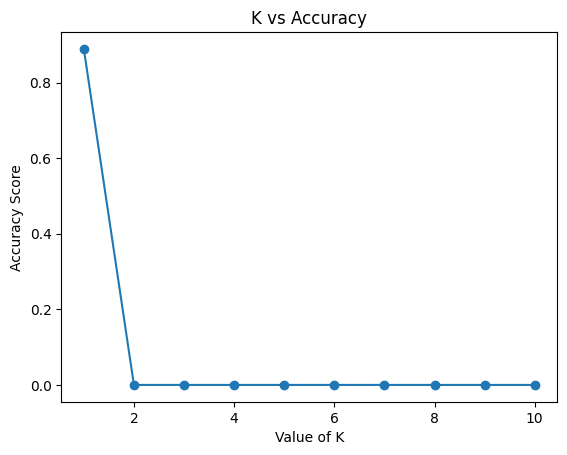

In [52]:
# 2. Clean data
df = df.select_dtypes(exclude=['object'])   # remove text columns
df = df.fillna(df.mean())                  # fill missing values

# 3. Split data
train_df = df.iloc[:50]
test_df = df.iloc[50:]

X_train = train_df.drop('fruit_label', axis=1)
y_train = train_df['fruit_label']
X_test = test_df.drop('fruit_label', axis=1)
y_test = test_df['fruit_label']

# 4 & 5. K from 1 to 10
k_values = range(1, 11)
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k) #calling the builtin function
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))

# 6. Plot
plt.plot(k_values, scores, marker='o')
plt.xlabel('Value of K')
plt.ylabel('Accuracy Score')
plt.title('K vs Accuracy')
plt.show()

# 1.11 Reflection

## Question 01: 
### Why is k usually chosen as an odd number?
##
## Answer: 
### In order to avoid tie in voting. For example if we have k=odd means k=4 then we may observe 2 vs 2 but 
### if we use k=even mens k=3 so it will always be 2 vs 1 or 1 vs 2

In [53]:
print()

## Question 02:
### What happens if k is too small (e.g., k = 1)? What if k is too large (e.g., k equals thetotal number of training points)?
##
## Answer: 
### if we choose k=1 that is too small it may choose the irrelevant neighbour which does not define it correctly and 
### if we choose k= too large then it will also choose any of the neighbour in the data set which may also not reflect its identity

In [45]:
print()

## Question 03:
### Why is KNN called a “lazy learner”? Is this an advantage or a disadvantage?
##
## Answer:
### Because it does not learn anything during training and stores aall the data and then makes predictions
### It is good because training is instant but also bad for large data set that will make it slow

In [46]:
print()

## Question 04:
###  If one feature ranges from 0 to 100 and another ranges from 0 to 10, how would this affect KNN? What could you do to fix it?
##
## Answer:
### Featureswith bigger range will dominate and it may result in irrelavent classification and smaller range will also cause same issue
### So we can scale them all from range 0 to 1 like we did in lab 10 or 11 so each feature contributes equally